# P5 — Assets & Allocation

L3 and L4 on one page: what the four investable assets actually did *conditional on
regime*, how volatile each has been, and what the naive vol-targeted regime tilt does
with those two facts.

The page answers four questions in order:

1. **Which assets?** — the exact 4-asset universe the backtest tilts across, re-derived
   read-only from the shipped `splice` config rather than typed out as a ticker list.
2. **What did they do per regime?** — annualized Sharpe and mean monthly return by
   (regime x asset), from `returns_by_regime_stats`.
3. **How volatile are they?** — trailing annualized EWMA vol, the same estimate the
   tilt sizes positions with.
4. **What weights does that imply?** — the tilt's weights month by month, every row
   checked against the exact weight-band contract before anything is drawn.

Nothing here sweeps an allocation or labeling hyperparameter (`target_vol_annual`,
`ewma_halflife_months`, the hysteresis thresholds, `K`, `lambda`, `n_restarts`): this
renders the **shipped config's** allocation math for the **shipped labeling** only
(D-14's no-sweep discipline, extended to L3/L4). Nothing here re-runs the walk-forward,
writes a checkpoint, or logs a trial.

**Prerequisites**

- `python scripts/build_platform_data.py` — builds the `monthly_raw` and
  `monthly_features` checkpoints this notebook reads.

In [1]:
%matplotlib inline
import logging

logging.basicConfig(level=logging.INFO)

from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.plotting import drift as pdrift
from trading_crab_lib.platform.plotting import allocation as pallocation
from trading_crab_lib.platform.assets.returns import returns_by_regime_stats
from trading_crab_lib.platform.honesty.holdout import DEFAULT_HOLDOUT_CUTOFF

cfg = load_platform_config()
# Never display cfg directly (T-06-01) -- it carries a live FRED_API_KEY.
# redacted_config() replaces every *api_key value before anything is shown.
print("platform config sections:", sorted(pplot.redacted_config(cfg).keys()))
print("allocation block:", pplot.redacted_config(cfg)["allocation"])
print("holdout cutoff:", DEFAULT_HOLDOUT_CUTOFF)

platform config sections: ['allocation', 'backtest', 'cv', 'data', 'fred_daily', 'fred_monthly', 'fred_vintage', 'holdout', 'labeling', 'macrotrends_monthly', 'multpl_monthly', 'paid_providers', 'registry', 'report', 'splice', 'taxonomy', 'tiingo', 'tripwire', 'universe']
allocation block: {'target_vol_annual': 0.1, 'ewma_halflife_months': 6, 'portfolio_vol_min_obs': 12, 'hysteresis': {'act_threshold': 0.7, 'unwind_threshold': 0.4}}
holdout cutoff: 2020-12-31


## The investable universe — the same four assets the backtest tilts across

`pallocation.investable_asset_returns` **re-derives** the asset universe from
`cfg["splice"]`, using the same dispatch rule `evaluation/report.py` uses to build what
it hands `run_backtest`: one column per non-cash splice class, keyed by that class's
`tradable` ticker. It is a read-only re-derivation, never an import of that private
construction — and never a hardcoded ticker list, which would silently drift the day a
class is added, renamed, or falls back to a different source.

Two properties matter and are worth stating out loud:

- **The universe is exactly SPY, TLT, IAU, USO.** This is not a wider satellite
  universe. If a class's source were unavailable, it would drop out here with a
  WARNING naming it — the same `_excluded` handling the report layer does.
- **Cash (FZFXX) is deliberately not one of them.** Cash is never a tilted risk
  position; it is the vol-target residual that earns `cash_ret`. It is loaded here
  alongside the assets, but it is not tilted into.

In [2]:
monthly_raw = pplot.load_platform_checkpoint(
    "monthly_raw", rebuild_hint="python scripts/build_platform_data.py"
)
monthly_features = pplot.load_platform_checkpoint(
    "monthly_features", rebuild_hint="python scripts/build_platform_data.py"
)
print(
    "monthly_raw:",
    monthly_raw.shape,
    monthly_raw.index.min().date(),
    "->",
    monthly_raw.index.max().date(),
)

asset_returns, cash_ret = pallocation.investable_asset_returns(monthly_raw, cfg)
print()
print("investable universe:", asset_returns.columns.tolist())
print("asset_returns:", asset_returns.shape)
print("cash_ret:", len(cash_ret), "months (the vol-target residual, never a tilted position)")
print()
print("inception (first observed month) per asset:")
for ticker in asset_returns.columns:
    print(f"  {ticker:5s} {asset_returns[ticker].first_valid_index().date()}")

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_raw  (776 rows × 45 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (708 rows × 53 cols)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved price_col -> 'sp500' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved div_yield_col -> 'div_yield' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'long_duration_tr': resolved yield_col -> 'fred_gs10' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'gold': resolved source_col -> 'gold_spot' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'oil': resolved source_col -> 'wti_crude' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'cash': resolved yield_col -> 'fred_tb3ms' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:Built 5 core research series: ['cash', 'equities_tr', 'gold', 'long_duration_tr', 'oil']


monthly_raw: (776, 45) 1962-01-31 -> 2026-08-31

investable universe: ['SPY', 'TLT', 'IAU', 'USO']
asset_returns: (776, 4)
cash_ret: 776 months (the vol-target residual, never a tilted position)

inception (first observed month) per asset:
  SPY   1962-02-28
  TLT   1962-02-28
  IAU   1985-03-31
  USO   1985-03-31


## The regime labeling — P3's entrypoint, reused verbatim

`pplot.compute_regime_labeling` is the **same** labeling entrypoint P3 and P4 call.
P5 does not fit a second labeler: two notebooks disagreeing about what "the regimes"
are would make every regime-conditional number on both pages unreadable.

It routes every write to the notebook scratch namespace
(`data/checkpoints/platform_notebook/`), never the production platform checkpoint
namespace (D-10). Opening this notebook cannot overwrite a pipeline artifact.

In [3]:
labeling_result = pplot.compute_regime_labeling(monthly_features, cfg)
states = labeling_result["regime_labels"]["state"]
print(
    "states:",
    len(states),
    "months",
    states.index.min().date(),
    "->",
    states.index.max().date(),
    "| distinct states:",
    sorted(states.unique().tolist()),
)

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint saved: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint saved: regime_confidences  (372 rows × 5 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint saved: regime_profiles  (5 rows × 2 cols)


INFO:trading_crab_lib.platform.labeling.diagnostics:Labeling Diagnostics (design §4.4, report-only D-02)
  state 0: occupancy=2.4%  median_sojourn=9.0mo  state 0: high credit_spread_baa_aaa, high fred_vix, high realized_vol_3m
  state 1: occupancy=15.6%  median_sojourn=58.0mo  state 1: high cape_shiller, low div_yield, low gold
  state 2: occupancy=32.3%  median_sojourn=60.0mo  state 2: low oil, low gold, high real_rate_level
  state 3: occupancy=32.0%  median_sojourn=59.5mo  state 3: low real_rate_level, low curve_10y3m, high gold
  state 4: occupancy=17.7%  median_sojourn=66.0mo  state 4: high oil, high gold, high curve_10y2y
  artifact: /home/user/claude-scratch-work/data/checkpoints/platform_notebook/labeling_diagnostics.parquet


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_confidences  (372 rows × 5 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_profiles  (5 rows × 2 cols)


Labeling Diagnostics (design §4.4, report-only D-02)
  state 0: occupancy=2.4%  median_sojourn=9.0mo  state 0: high credit_spread_baa_aaa, high fred_vix, high realized_vol_3m
  state 1: occupancy=15.6%  median_sojourn=58.0mo  state 1: high cape_shiller, low div_yield, low gold
  state 2: occupancy=32.3%  median_sojourn=60.0mo  state 2: low oil, low gold, high real_rate_level
  state 3: occupancy=32.0%  median_sojourn=59.5mo  state 3: low real_rate_level, low curve_10y3m, high gold
  state 4: occupancy=17.7%  median_sojourn=66.0mo  state 4: high oil, high gold, high curve_10y2y
  artifact: /home/user/claude-scratch-work/data/checkpoints/platform_notebook/labeling_diagnostics.parquet
states: 372 months 1990-01-31 -> 2020-12-31 | distinct states: [0, 1, 2, 3, 4]


## L3 — what each asset did, conditional on regime

`returns_by_regime_stats` is the Phase-4 statistics function the allocation tilt itself
ranks assets with. This page renders **that** table, not a parallel statistic computed
here — a second implementation that disagreed with the tilt's own inputs would make the
weights below unexplainable.

`n_obs` is shown deliberately. A (regime, asset) cell built from a handful of months is
low-confidence, and the tilt logs it as such rather than hiding it. State 0 is the rare,
short, high-volatility state — read its row with that in mind.

In [4]:
stats_df = returns_by_regime_stats(asset_returns, states)
print(stats_df.to_string(index=False))

 regime asset  mean_monthly_return  std_monthly_return  sharpe_annualized  hit_rate  max_drawdown  n_obs
      0   SPY            -0.031609            0.092611          -1.182320  0.222222     -0.366714      9
      0   TLT             0.008586            0.039379           0.755317  0.444444     -0.062197      9
      0   IAU             0.020921            0.093036           0.778989  0.666667     -0.187848      9
      0   USO            -0.042714            0.194070          -0.762443  0.444444     -0.585601      9
      1   SPY             0.008734            0.041893           0.722190  0.568966     -0.286757     58
      1   TLT             0.007345            0.016573           1.535226  0.689655     -0.089563     58
      1   IAU            -0.003151            0.040533          -0.269261  0.362069     -0.293955     58
      1   USO             0.001680            0.106114           0.054847  0.448276     -0.461903     58
      2   SPY             0.009014            0.030004 

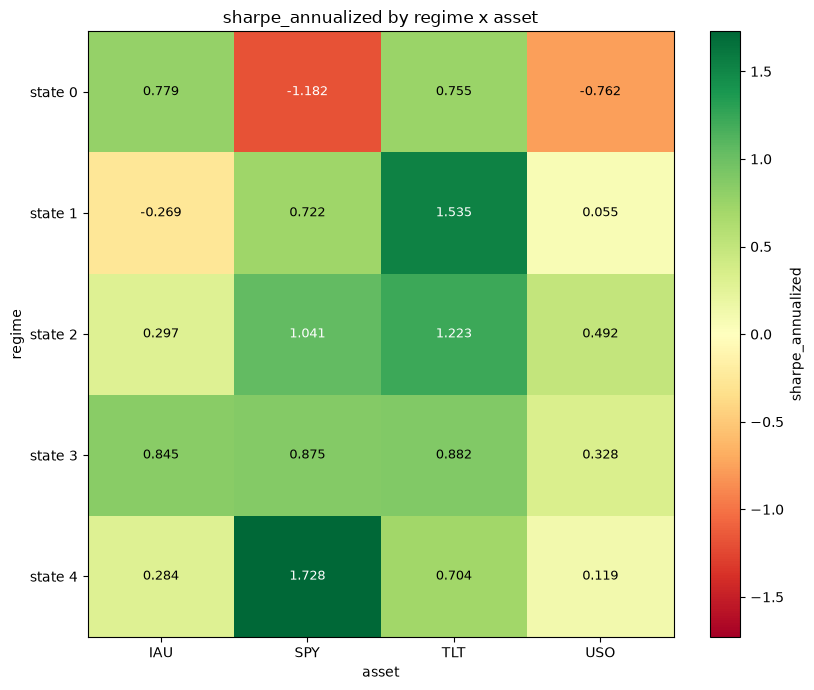

In [5]:
pallocation.plot_returns_by_regime_heatmap(stats_df, metric="sharpe_annualized");

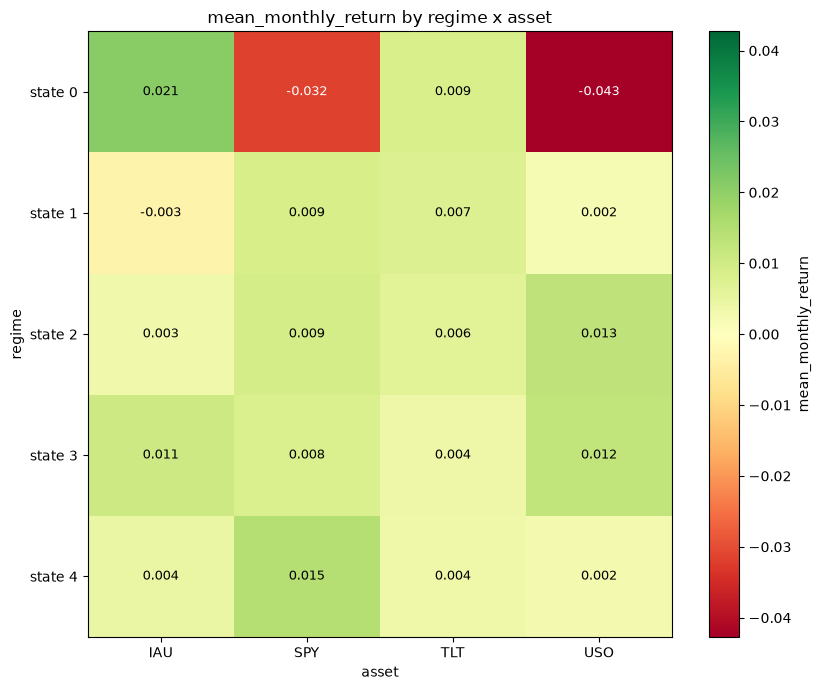

In [6]:
pallocation.plot_returns_by_regime_heatmap(stats_df, metric="mean_monthly_return");

## L3 — trailing annualized EWMA volatility

The same `assets/vol.ewma_vol` estimate the tilt sizes positions with (position scale
is `min(1, target_vol / sigma_hat_port)`), on the shipped 6-month halflife. Each line is
computed on that asset's own observed history, so a late-inception ticker is not
penalized by leading NaNs.

**What to look for:** a *persistent* shift in an asset's baseline vol level — not the
spikes, which are crises and are supposed to be there. A step change in the floor
(e.g. after the early 1990s, or after 2008) means the tilt has been sizing that asset
against a different risk regime than the one its regime-conditional Sharpe was measured
in. Gold (IAU) and oil (USO) only begin in 1985 here; before then the universe is
equities and duration only, which is exactly what the weights panel below shows.

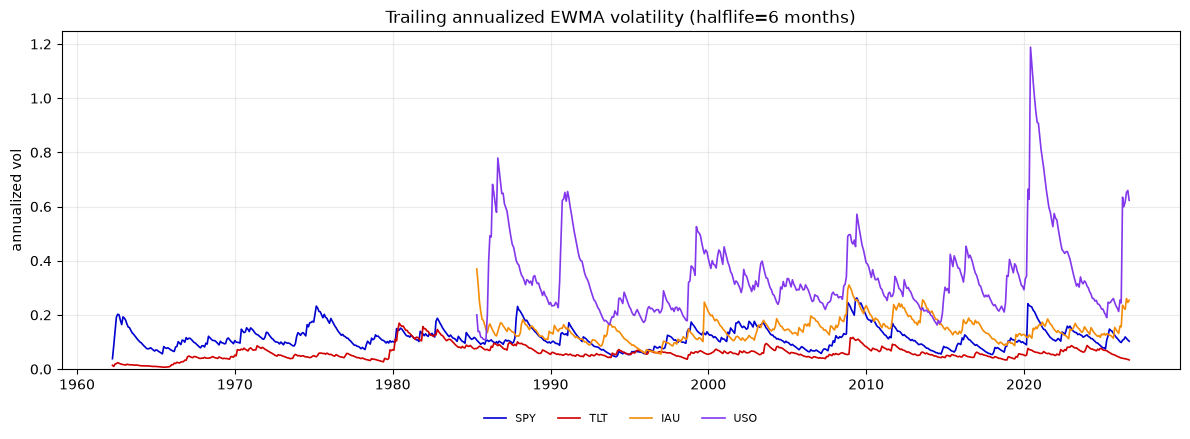

In [7]:
pallocation.plot_ewma_vol_timeline(asset_returns);

## L4 — the tilt's weights over time

**This panel is an illustrative, hindsight-informed rendering of the allocation math.
It is not a live weekly recommendation, and it is not what the real strategy held.**
Three separate reasons, all of which matter:

1. **It is smoothed, not filtered.** The tilt is driven by a one-hot probability on the
   *full-sample* smoothed state at each date, and the regime-conditional statistics
   feeding it are computed once over the entire label history. Both are non-causal by
   construction — every decision date is scored partly on months that came after it.
2. **v1 has no live scoring path at all.** There is nothing here that could be a
   recommendation for this week, because that path does not exist yet.
3. **The real walk-forward strategy is a different computation**, refit per window
   against a real-time nowcaster, and it belongs to P6. `run_backtest()` and
   `run_full_backtest_evaluation()` are not called anywhere in this notebook.

One kind of hindsight is intended (the regime *labels*); asset **existence** is not. An
asset gets weight only from its own inception month onward — without that filter, IAU
and USO would draw full-sample Sharpe entries and take real weight decades before they
were issued.

Before anything is drawn, the most recent weight row is checked against
`pdrift.assert_portfolio_weights_plausible` — every weight in `[0, 1]`, assets plus cash
summing to exactly 1.0, long-only by design (no shorts, no options). That function is
the single source of the band; this notebook does not re-derive the rule. **An
impossible weight stops the notebook right here** rather than rendering a
plausible-looking chart of invalid weights.

In [8]:
weights_df = pallocation.compute_smoothed_tilt_weights_over_time(states, asset_returns, cfg)
print(
    "weights:",
    weights_df.shape,
    weights_df.index.min().date(),
    "->",
    weights_df.index.max().date(),
)

# Guard BEFORE rendering -- an impossible weight row stops the notebook here.
asset_columns = list(asset_returns.columns)
last_row = weights_df.iloc[-1]
pdrift.assert_portfolio_weights_plausible(
    last_row[asset_columns], cash_weight=float(last_row["cash"])
)
print("\nlast row passes the exact weight-band contract:")
print(last_row.to_string())
print(f"\n  sum(assets) + cash = {float(last_row.sum()):.12f}")

# The same contract, applied to every rendered row -- not only the last one.
for timestamp, row in weights_df.iterrows():
    pdrift.assert_portfolio_weights_plausible(
        row[asset_columns], cash_weight=float(row["cash"])
    )
print(f"  all {len(weights_df)} rendered rows pass the same check")

weights: (360, 5) 1991-01-31 -> 2020-12-31

last row passes the exact weight-band contract:
SPY     0.220821
TLT     0.222608
IAU     0.213276
USO     0.082786
cash    0.260509

  sum(assets) + cash = 1.000000000000


  all 360 rendered rows pass the same check


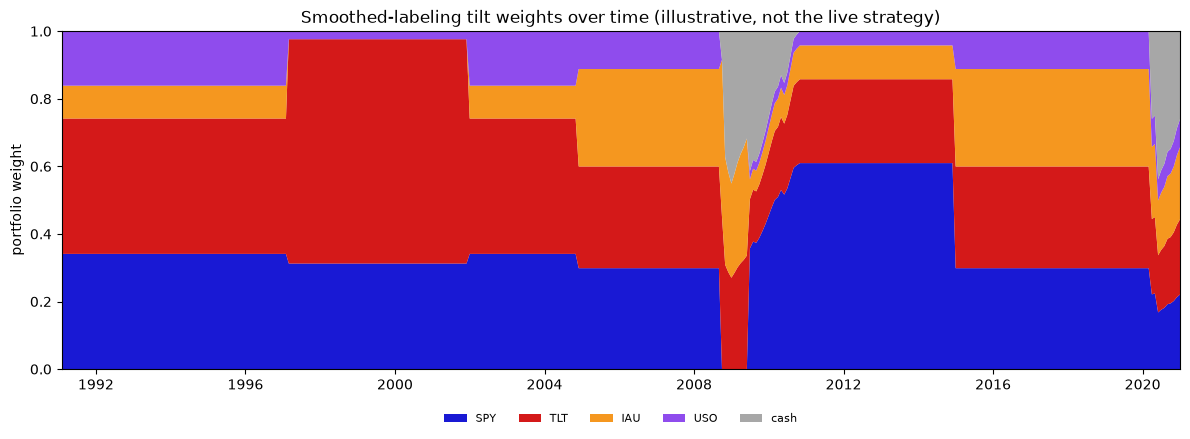

In [9]:
pallocation.plot_tilt_weights_over_time(weights_df);

## Full-span asset-return drift (D-06 / D-07)

The fence in this project is on **fitting**, not on **looking**. Everything above is
computed on the dev-bounded frame; this panel alone reads the full span through today,
purely to look. No model here is fitted, tuned, or selected against post-2021 data.

Why an allocation page carries a drift panel: the tilt ranks assets by regime-conditional
Sharpe estimated on the pre-2021 window. If an asset's return distribution has moved
since, the ranking it drives is stale even though every number on this page still looks
plausible and no guard fires. A large standardized mean shift relative to the pre-2021
baseline is the visible symptom.

Drift is measured against the pre-2021 baseline, and it is scale-invariant — so it
cannot catch a uniform units error. That is the plausibility guards' job (P2's), not
this table's. Per D-07, an observation here that would **change a decision** belongs in
`.planning/POST-2020-OBSERVATIONS.md` with its date; deciding something is
decision-changing is an operator judgement, not an automatic consequence of a flagged row.

In [10]:
full_raw = pplot.load_full_span_checkpoint(
    "monthly_raw", rebuild_hint="python scripts/build_platform_data.py"
)
print(
    "full span:",
    full_raw.shape,
    full_raw.index.min().date(),
    "->",
    full_raw.index.max().date(),
)

full_asset_returns, _ = pallocation.investable_asset_returns(full_raw, cfg)
drift_df = pdrift.drift_report(
    full_asset_returns, list(full_asset_returns.columns), cutoff=DEFAULT_HOLDOUT_CUTOFF
)
print(f"\n{len(drift_df)} assets; {int(drift_df['flag'].sum())} flagged\n")
print(drift_df.to_string(index=False))

INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_raw  (776 rows × 45 cols)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved price_col -> 'sp500' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'equities_tr': resolved div_yield_col -> 'div_yield' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'long_duration_tr': resolved yield_col -> 'fred_gs10' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:splice 'gold': resolved source_col -> 'gold_spot' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'oil': resolved source_col -> 'wti_crude' (candidate 1 of 2)


INFO:trading_crab_lib.platform.splice:splice 'cash': resolved yield_col -> 'fred_tb3ms' (candidate 1 of 1)


INFO:trading_crab_lib.platform.splice:Built 5 core research series: ['cash', 'equities_tr', 'gold', 'long_duration_tr', 'oil']


full span: (776, 45) 1962-01-31 -> 2026-08-31

4 assets; 0 flagged

column  n_baseline  n_current  baseline_mean  baseline_std  current_mean  standardized_mean_shift  ks_statistic  ks_pvalue  pct_beyond_2sigma  flag
   TLT         707         68       0.005540      0.019259     -0.001829                -0.382637      0.177531   0.034762           0.044118 False
   IAU         430         68       0.005341      0.044265      0.013814                 0.191410      0.151231   0.121603           0.073529 False
   SPY         707         68       0.008719      0.035829      0.012564                 0.107294      0.103128   0.489563           0.044118 False
   USO         430         68       0.007185      0.108992      0.014238                 0.064708      0.074487   0.873396           0.029412 False


## What an operator is checking on this page

1. **Regime-conditional Sharpe by asset** — does the ranking within each regime make
   economic sense, and is any cell driven by a handful of months (`n_obs`)? The tilt
   ranks on exactly these numbers, so an implausible cell here becomes a weight there.
2. **Vol regime shifts** — has any asset's *baseline* vol level stepped, rather than
   merely spiked? A step means the sizing input and the Sharpe input were measured in
   different risk regimes.
3. **Weight-band compliance** — every rendered row satisfies
   `assert_portfolio_weights_plausible`. This is the check that would catch a
   normalization defect in `allocation/tilt.py` instead of rendering a plausible-looking
   chart of invalid weights, and it runs before the chart is drawn.
4. **Asset-return drift** — which assets' current-era distributions have moved away
   from the pre-2021 window the regime-conditional statistics were estimated on.

**P5 carries no sign-off cell and no per-run gate.** The single cold-start sign-off in
the whole notebook suite lives in P3 and stays there (D-15); a second place to record a
verdict would make it ambiguous which one is the record. P5 is a periodic check
surface — it states what to look for and stops there.

**And the weights panel is illustrative, never a trading instruction.** It shows that
the allocation math works over history when handed a regime path. It does not say what
to hold.